# Overlap FINAL — Logistic Regression SW_pos1.5, PCA train-only

Notebook final limpio para el modelo de victim–perpetrator overlap.

Pipeline oficial:
1. split primero;
2. scaler fit solo en train;
3. PCA fit solo en train;
4. selección de componentes por varianza acumulada 95%;
5. LogisticRegression con sample weight positivo multiplicador 1.5;
6. evaluación held-out con threshold = 0.500.

No depende de salidas del notebook DNN. Genera sus propios artefactos finales.

# Intersection clasificator
Script backend para construir y evaluar el clasificador de la intersección víctima-perpetrador.<br>
Junta todas las celdas de código en una.<br>
Construye la tabla con datos, el conjunto de entrenamiento y validación.<br>
Entrena el modelo Decission Tree, lo evalua y muestra los resultados de la evaluación como resultado final.<br>

### Pre-condición
Tu gráfica puede ayudarte con el cálculo, comprúebalo ejecutando el código de aqui abajo👇

In [1]:
# Optional Colab loader. The main cell below also reads from ./../data/ directly.
from pathlib import Path
import pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive', readonly=True)
    DATA_DIR = Path('/content/drive/MyDrive/data')
    feat_df = pd.read_csv(DATA_DIR / 'lista_global_vars.csv')
    target_df = pd.read_csv(DATA_DIR / 'target_col.csv').fillna(0)
    print('Datos cargados desde Google Drive:', DATA_DIR)
except Exception as e:
    print('No se usa Google Colab/Drive en este entorno. Se cargarán datos desde ./../data en la celda principal.')
    print('Detalle:', e)


No se usa Google Colab/Drive en este entorno. Se cargarán datos desde ./../data en la celda principal.
Detalle: No module named 'google.colab'


In [2]:
# ============================================================
# CONFIGURACIÓN FINAL OVERLAP — LOGREG SW_pos1.5 PCA TRAIN-ONLY
# ============================================================
from pathlib import Path
import os
import random
import numpy as np

PCA_THRESHOLD = 0.95          # Varianza acumulada mínima para seleccionar PCs
THRESHOLD = 0.500             # Umbral de probabilidad para clasificar overlap=1
THRESHOLD_SWEEP_STEP = 0.001  # Paso para barrer thresholds en la celda final
RANDOM_STATE = 42             # Semilla para split, numpy, random
POS_WEIGHT_MULTIPLIER = 1.5   # SW_pos1.5 seleccionado en comparación de modelos

OUTPUT_BASE_DIR = Path("./overlap_final")
RUN_NAME = f"overlap_LOGREG_SW_pos1p5_PCA_trainonly_FINAL_PCA{int(PCA_THRESHOLD*100):03d}_thr{str(THRESHOLD).replace('.', 'p')}_seed{RANDOM_STATE}"
ALLOW_OVERWRITE_OUTPUT_DIR = False

def make_unique_dir(base_dir: Path, run_name: str, allow_overwrite: bool = False) -> Path:
    out = base_dir / run_name
    if allow_overwrite or not out.exists():
        return out
    i = 2
    while True:
        candidate = base_dir / f"{run_name}_v{i:02d}"
        if not candidate.exists():
            return candidate
        i += 1

OUTPUT_DIR = make_unique_dir(OUTPUT_BASE_DIR, RUN_NAME, ALLOW_OVERWRITE_OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Configuración activa:")
print(f"  PCA_THRESHOLD = {PCA_THRESHOLD}")
print(f"  THRESHOLD = {THRESHOLD}")
print(f"  RANDOM_STATE = {RANDOM_STATE}")
print(f"  POS_WEIGHT_MULTIPLIER = {POS_WEIGHT_MULTIPLIER}")
print(f"  OUTPUT_DIR = {OUTPUT_DIR}")


Configuración activa:
  PCA_THRESHOLD = 0.95
  THRESHOLD = 0.5
  RANDOM_STATE = 42
  POS_WEIGHT_MULTIPLIER = 1.5
  OUTPUT_DIR = overlap_final/overlap_LOGREG_SW_pos1p5_PCA_trainonly_FINAL_PCA095_thr0p5_seed42_v02


In [3]:
# Optional GPU check, not required for the final logistic model.
try:
    import torch
    print('torch.cuda.is_available():', torch.cuda.is_available())
except Exception as e:
    print('Torch no disponible o no necesario:', e)


torch.cuda.is_available(): False


### Ejecución
El siguiente código realiza el proceso de clasificación explicado al comienzo.

OUTPUT_DIR activo: overlap_final/overlap_LOGREG_SW_pos1p5_PCA_trainonly_FINAL_PCA095_thr0p5_seed42_v02
DATA_DIR: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/data
Dim características:  (4024, 29)
Dim target:  (4024, 11)
Valores faltantes:  0
['VÍCTIMA', 'PERPETRADOR', 'VICTIMA_PERPETRADOR', 'POLIVICTIMIZACION', 'POLIPERPETRACION', 'SOLO.VICTIMA', 'SOLO.PERPETRADOR', 'NO.VICT_NO.PERP', 'V.O', 'P.SUM.TOTAL', 'V.SUM.TOTAL']


/var/folders/5x/ww_kz7lx5wz4pn1typnpk_g40000gn/T/ipykernel_85964/3319839594.py:742: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


,PAÍS,ETNIA.BN,EDAD,FUGAS.BN,ABUSOSUBS1,ABUSOSUBS2,CONVIVEN.1,CONVIVEN.2,CONVIVEN.3,CONVIVEN.4,...,APOYO.MEAN,APOYO.MEDIAN,APOYO.VAR,MORAL.MEAN,MORAL.VAR,PORNO.T,GENERO.BN0,ORIENTSEX.BN0,GENERO.BN1,ORIENTSEX.BN1
0,True,False,16.0,False,4,4,1.0,1.0,0.0,0.0,...,4.000000,4.0,0.000000,5.0,0.00,1.0,False,True,True,False
1,True,False,16.0,False,3,2,1.0,1.0,0.0,0.0,...,3.428571,4.0,0.530612,2.8,0.56,4.0,True,True,False,False
2,True,False,17.0,False,3,3,1.0,1.0,0.0,0.0,...,3.285714,4.0,0.775510,4.2,0.96,3.0,False,True,True,False
3,True,False,16.0,False,3,3,1.0,1.0,0.0,0.0,...,3.285714,4.0,0.775510,4.0,0.40,4.0,True,True,False,False
4,True,False,17.0,False,3,3,1.0,1.0,0.0,0.0,...,3.571429,4.0,0.530612,4.4,1.44,2.0,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3762,True,False,14.0,False,0,0,1.0,1.0,0.0,0.0,...,3.285714,4.0,1.061224,3.6,0.24,1.0,False,True,True,False
3763,False,False,14.0,True,2,0,1.0,1.0,0.0,0.0,...,2.714286,3.0,1.061224,4.4,0.64,1.0,False,True,True,False
3764,True,False,14.0,False,2,0,1.0,1.0,0.0,0.0,...,3.714286,4.0,0.489796,4.8,0.16,1.0,False,True,True,False
3765,False,False,14.0,False,0,0,1.0,1.0,0.0,0.0,...,3.714286,4.0,0.204082,5.0,0.00,1.0,False,True,True,False


MATCH df_target vs count-based overlap definition: 1.0
df_target positives: 713
count-based overlap positives: 713
PCA train-only seleccionado: 18 componentes (threshold=0.95)
Train n=2825 positives=535; Val n=942 positives=178
pos_rate_train=0.189381
base_pos_weight=4.280374
positive_class_final_weight=6.420561

=== FINAL REPORT — OVERLAP LOGREG SW_pos1.5 ===
              precision    recall  f1-score   support

           0      0.923     0.535     0.678       764
           1      0.289     0.809     0.425       178

    accuracy                          0.587       942
   macro avg      0.606     0.672     0.552       942
weighted avg      0.803     0.587     0.630       942


=== METRICS FINAL ===
                             0
threshold             0.500000
accuracy              0.587049
balanced_accuracy     0.672165
precision_ppv         0.288577
recall_sensitivity    0.808989
specificity           0.535340
npv                   0.923251
f1_positive           0.425406
TP      

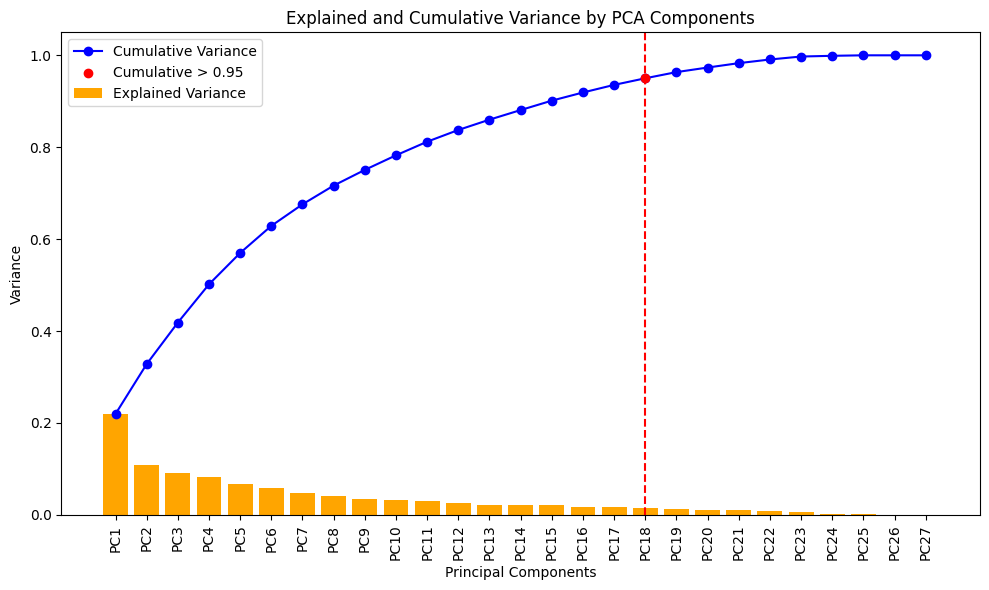

,PC,var_1,loading_1,var_2,loading_2,var_3,loading_3,var_4,loading_4,var_5,loading_5
0,PC1,GENERO.BN0,0.661408,GENERO.BN1,-0.661408,PORNO.T,0.283769,ORIENTSEX.BN1,-0.125134,ORIENTSEX.BN0,0.125134
1,PC2,CONVIVEN_H,0.663658,CONVIVEN.2,0.532331,ETNIA.BN,-0.200309,ORIENTSEX.BN0,0.193844,ORIENTSEX.BN1,-0.193844
2,PC3,ORIENTSEX.BN1,0.618468,ORIENTSEX.BN0,-0.618468,CONVIVEN_H,0.285456,PORNO.T,0.187334,CONVIVEN.2,0.185774
3,PC4,ETNIA.BN,0.601288,CONVIVEN_H,0.590107,CONVIVEN.2,-0.339355,PAÍS,-0.276534,CONVIVEN.3,0.159191
4,PC5,ABUSOSUBS1,0.447878,EDAD,0.441129,ETNIA.BN,-0.387802,CONVIVEN.2,-0.311232,ABUSOSUBS2,0.270548
5,PC6,CONVIVEN.2,0.574141,ETNIA.BN,0.410065,FUGAS.BN,0.338259,EDAD,0.290556,ABUSOSUBS1,0.256728
6,PC7,FUGAS.BN,0.538397,EDAD,-0.498498,APOYO.MEDIAN,-0.337992,APOYO.VAR,0.301595,APOYO.MEAN,-0.292547
7,PC8,FUGAS.BN,0.483821,APOYO.MEDIAN,0.454137,EDAD,-0.392356,APOYO.MEAN,0.382890,APOYO.VAR,-0.382695
8,PC9,CONVIVEN_0,0.824569,CONVIVEN.1,-0.426904,FUGAS.BN,-0.199166,ETNIA.BN,-0.158366,CONVIVEN.2,0.146902
9,PC10,PORNO.T,0.702710,EDAD,-0.403165,FUGAS.BN,-0.367484,ABUSOSUBS1,0.210835,CONVIVEN_0,-0.204435


              precision    recall  f1-score   support

           0       0.92      0.54      0.68       764
           1       0.29      0.81      0.43       178

    accuracy                           0.59       942
   macro avg       0.61      0.67      0.55       942
weighted avg       0.80      0.59      0.63       942


Artefactos guardados en: overlap_final/overlap_LOGREG_SW_pos1p5_PCA_trainonly_FINAL_PCA095_thr0p5_seed42_v02


In [4]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import os
import re
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import recall_score
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import json
import itertools
import random
from pathlib import Path
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

# ============================================================
# OUTCOME / META CONFIG
# ============================================================
OUTCOME = "overlap"
V_COL = "V.SUM.TOTAL"
P_COL = "P.SUM.TOTAL"
SUBGROUP_COLS = [
    "PAÍS",
    "ETNIA.BN",
    "EDAD",
    "GENERO_BIN_0",
    "GENERO_BIN_1",
    "GENERO_BIN_2",
    "ORIENTSEX.BN_1",
    "ORIENTSEX.BN_2",
    "ORIENTSEX.BN_3",
]

# ============================================================
# REPRODUCIBILIDAD Y SALIDAS
# ============================================================
try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path('./content/intersection')

OUTPUT_DIR = Path(OUTPUT_DIR)
(OUTPUT_DIR / 'model').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'outputs').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'data_split').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'data_reference').mkdir(parents=True, exist_ok=True)

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(f'OUTPUT_DIR activo: {OUTPUT_DIR}')

def perform_pca(df: pd.DataFrame,
                save_scaler_path: str = "models/scaler_minmax.pkl",
                save_pca_path: str = "models/modelo_pca.pkl",
                save_means_path: str = "models/medias_escalado.csv"
               ):
    """
    Realiza un PCA sobre el DataFrame de entrada y devuelve:
      1) df_pca: DataFrame con las componentes principales (PC1, PC2, …).
      2) df_var: DataFrame con las varianzas explicada y acumulada por componente.
      3) scaler: MinMaxScaler ya entrenado.
      4) pca: PCA ya entrenado.
      5) means: Series con la media de cada variable tras escalado.
    Además guarda automáticamente el scaler, el modelo PCA y el vector de medias en rutas predeterminadas.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame numérico de entrada (n muestras × p variables).
    save_scaler_path : str
        Ruta por defecto donde volcar el scaler (pickle).
    save_pca_path : str
        Ruta por defecto donde volcar el modelo PCA (pickle).
    save_means_path : str
        Ruta por defecto donde guardar las medias de cada variable tras escalado (CSV).

    Retorna
    -------
    df_pca : pd.DataFrame
        Transformación PCA (n muestras × p componentes), columnas PC1…PCp.
    df_var : pd.DataFrame
        Tabla con columnas:
          - PC: nombre de la componente ("PC1", "PC2", …)
          - explained variance: varianza explicada por cada componente
          - cumulative variance: varianza acumulada hasta esa componente
    scaler : MinMaxScaler
        Objeto scaler ajustado (fit).
    pca : PCA
        Objeto PCA ajustado (fit).
    means : pd.Series
        Media de cada variable tras el escalado (para centrar nuevos datos).
    """
    # Crear carpetas si no existen

    os.makedirs(os.path.dirname(save_scaler_path), exist_ok=True)
    os.makedirs(os.path.dirname(save_pca_path), exist_ok=True)
    os.makedirs(os.path.dirname(save_means_path), exist_ok=True)

    # 1) Escalado al rango [0,1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler.fit_transform(df.values)

    # 2) Cálculo de medias para centrar
    means_array = X_scaled.mean(axis=0)
    means = pd.Series(means_array, index=df.columns, name='mean')

    # 3) Centramos cada variable usando las medias calculadas
    X_centered = X_scaled - means_array

    # 4) Ajustar y transformar PCA
    pca = PCA(n_components=df.shape[1])
    comps = pca.fit_transform(X_centered)

    # 5) DataFrame de componentes principales
    cols = [f"PC{i+1}" for i in range(df.shape[1])]
    df_pca = pd.DataFrame(comps, index=df.index, columns=cols)

    # 6) Varianzas explicada y acumulada
    var_ratio = pca.explained_variance_ratio_
    cum_var  = var_ratio.cumsum()
    df_var = pd.DataFrame({
        "PC": cols,
        "explained variance": var_ratio,
        "cumulative variance": cum_var
    })

    # 7) Guardar a disco en rutas por defecto
    joblib.dump(scaler, save_scaler_path)
    joblib.dump(pca, save_pca_path)
    means.to_csv(save_means_path, header=True)

    return df_pca, df_var, scaler, pca, means

def plot_pca_variance(df_var):
    """
    Genera un barplot de la varianza explicada (barras amarillas) y un lineplot
    de la varianza acumulada (línea azul), marcando con un punto rojo donde
    la varianza acumulada supera el 0.95.

    Parámetros
    ----------
    df_var : pandas.DataFrame
        DataFrame con columnas:
          - "PC": nombres de componentes ("PC1", "PC2", …)
          - "explained variance": varianza explicada por componente
          - "cumulative variance": varianza acumulada
    """
    # Preparar datos
    x = range(len(df_var))
    explained = df_var['explained variance']
    cumulative = df_var['cumulative variance']

    # Crear la figura
    plt.figure(figsize=(10, 6))

    # Barplot de varianza explicada
    plt.bar(x, explained, color='orange', label='Explained Variance')

    # Lineplot de varianza acumulada
    plt.plot(x, cumulative, color='blue', marker='o', label='Cumulative Variance')

    # Punto rojo donde cumulative > 0.95
    above_idx = df_var.index[cumulative > 0.95]
    if not above_idx.empty:
        idx0 = above_idx[0]
        plt.scatter(idx0, cumulative[idx0], color='red', zorder=5, label='Cumulative > 0.95')
        plt.axvline(x=idx0, color='red', linestyle='--')

    # Configuración de ejes y leyenda
    plt.xticks(x, df_var['PC'], rotation=90)
    plt.xlabel('Principal Components')
    plt.ylabel('Variance')
    plt.title('Explained and Cumulative Variance by PCA Components')
    plt.legend()
    plt.tight_layout()
    plt.show()


def select_PCA_df(df_var: pd.DataFrame, df_PCA: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """
    Selecciona las primeras i componentes principales de df_PCA donde i es el número de componente
    tal que el primer valor de 'cumulative variance' en df_var supera el umbral dado.

    Args:
        df_var (pd.DataFrame): DataFrame con columnas 'PC' (etiquetas 'PC1', 'PC2', ...) y
                               'cumulative variance' (float entre 0 y 1).
        df_PCA (pd.DataFrame): DataFrame resultante de una PCA, con tantas columnas como componentes.
        threshold (float): Umbral de varianza acumulada entre 0 y 1.

    Returns:
        pd.DataFrame: Subset de df_PCA con las primeras i columnas.
    """
    # Validación de umbral
    if not (0 <= threshold <= 1):
        raise ValueError("El umbral debe estar entre 0 y 1")

    # Buscar el primer índice que supere el threshold
    mask = df_var['cumulative variance'] > threshold
    if not mask.any():
        raise ValueError("Ningún valor de varianza acumulada supera el umbral dado")

    idx = mask.idxmax()  # índice del primer True
    pc_label = df_var.loc[idx, 'PC']  # p.ej. 'PC3'

    # Extraer i del string 'PCi'
    match = re.match(r'PC(\d+)', pc_label)
    if not match:
        raise ValueError(f"Formato inesperado en etiqueta PC: {pc_label}")
    i = int(match.group(1))

    # Seleccionar las primeras i columnas de df_PCA
    return df_PCA.iloc[:, :i]

def LOGREG_overlap_classifier(
    df_features: pd.DataFrame,
    df_target: pd.Series,
    output_dir: str,
    random_state: int = 42,
    prediction_threshold: float = 0.5,
    pca_threshold: float = 0.95,
    pos_weight_multiplier: float = 1.5,
    df_meta_source: pd.DataFrame | None = None,
):
    """
    Modelo final para victim–perpetrator overlap.

    Pipeline:
    - train/test split primero;
    - MinMaxScaler fit solo en train;
    - centrado con medias de train;
    - PCA fit solo en train;
    - selección de PCs por varianza acumulada;
    - LogisticRegression con sample_weight positivo = base_pos_weight * pos_weight_multiplier;
    - evaluación held-out con threshold fijo.

    Guarda:
    - model/scaler_minmax.pkl
    - model/modelo_pca.pkl
    - model/medias_escalado.csv
    - model/final_overlap_logreg_SW_pos1p5.joblib
    - X_train.csv, X_val.csv, y_train.csv, y_val.csv
    - predictions_with_probs.csv
    - outputs/metrics_final.csv
    - outputs/best_report.json
    - outputs/config.json
    - splits_indices.json
    """
    output_dir = Path(output_dir)
    (output_dir / 'model').mkdir(parents=True, exist_ok=True)
    (output_dir / 'outputs').mkdir(parents=True, exist_ok=True)
    (output_dir / 'data_split').mkdir(parents=True, exist_ok=True)
    (output_dir / 'data_reference').mkdir(parents=True, exist_ok=True)

    random.seed(random_state)
    np.random.seed(random_state)

    # 1. Target y split
    y_series = df_target.astype(int)
    y = y_series.values

    all_pos = np.arange(len(df_features))
    train_pos, val_pos = train_test_split(
        all_pos,
        test_size=0.25,
        random_state=random_state,
        stratify=y
    )

    original_idx = df_features.index.to_numpy()
    train_idx = original_idx[train_pos]
    val_idx = original_idx[val_pos]

    splits = {
        'random_state': int(random_state),
        'test_size': 0.25,
        'stratify': True,
        'train_pos': train_pos.tolist(),
        'val_pos': val_pos.tolist(),
        'train_original_index': train_idx.tolist(),
        'val_original_index': val_idx.tolist(),
        'pca_scope': 'train_only'
    }
    with open(output_dir / 'splits_indices.json', 'w', encoding='utf-8') as f:
        json.dump(splits, f, indent=2)
    pd.DataFrame({'train_pos': train_pos}).to_csv(output_dir / 'train_indices.csv', index=False)
    pd.DataFrame({'val_pos': val_pos}).to_csv(output_dir / 'test_indices.csv', index=False)


    # 1b. Metadata alineada al split final, para subgroup audit y threshold sensitivity.
    #     Se alinea por POSICIÓN porque el split se hizo sobre all_pos y luego se mapearon
    #     posiciones -> idx_original analítico. Esto evita el error de cruzar contra target_col.csv bruto.
    meta_train = None
    meta_val = None
    if df_meta_source is not None:
        if len(df_meta_source) != len(df_features):
            raise ValueError(
                f"df_meta_source debe tener la misma longitud que df_features. "
                f"df_meta_source={len(df_meta_source)}, df_features={len(df_features)}"
            )

        meta_source = df_meta_source.copy().reset_index(drop=True)

        required_cols = [V_COL, P_COL]
        missing_required = [c for c in required_cols if c not in meta_source.columns]
        if missing_required:
            raise ValueError(f"df_meta_source no contiene columnas requeridas: {missing_required}")

        meta_source[V_COL] = pd.to_numeric(meta_source[V_COL], errors='coerce')
        meta_source[P_COL] = pd.to_numeric(meta_source[P_COL], errors='coerce')

        y_from_counts_all = ((meta_source[V_COL] >= 1) & (meta_source[P_COL] >= 1)).astype(int).to_numpy()
        match_all = float((y_from_counts_all == y.astype(int)).mean())

        print("MATCH df_target vs count-based overlap definition:", match_all)
        print("df_target positives:", int(y.sum()))
        print("count-based overlap positives:", int(y_from_counts_all.sum()))

        if match_all < 0.999:
            raise RuntimeError(
                "df_meta_source no está alineado con df_features/df_target. "
                "No continuar: el export row-level quedaría mal alineado."
            )

        keep_meta_cols = [V_COL, P_COL] + [c for c in SUBGROUP_COLS if c in meta_source.columns]
        # Conservamos INTERSECT si existe, solo para trazabilidad.
        if 'INTERSECT' in meta_source.columns and 'INTERSECT' not in keep_meta_cols:
            keep_meta_cols.append('INTERSECT')

        meta_train = meta_source.iloc[train_pos][keep_meta_cols].copy()
        meta_val = meta_source.iloc[val_pos][keep_meta_cols].copy()
        meta_train['idx_original'] = train_idx.astype(int)
        meta_val['idx_original'] = val_idx.astype(int)

        meta_train.to_csv(output_dir / 'data_split' / 'meta_train_aligned.csv', index=False)
        meta_val.to_csv(output_dir / 'data_split' / 'meta_val_aligned.csv', index=False)

    # 2. PCA train-only
    X_train_raw = df_features.iloc[train_pos].copy()
    X_val_raw = df_features.iloc[val_pos].copy()
    y_train = y[train_pos]
    y_val = y[val_pos]

    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler.fit_transform(X_train_raw.values)
    X_val_scaled = scaler.transform(X_val_raw.values)

    means_array = X_train_scaled.mean(axis=0)
    means = pd.Series(means_array, index=X_train_raw.columns, name='mean')
    X_train_centered = X_train_scaled - means_array
    X_val_centered = X_val_scaled - means_array

    pca = PCA(n_components=X_train_raw.shape[1])
    X_train_pca_all = pca.fit_transform(X_train_centered)
    X_val_pca_all = pca.transform(X_val_centered)

    var_ratio = pca.explained_variance_ratio_
    cum_var = var_ratio.cumsum()
    pc_all_cols = [f"PC{i+1}" for i in range(X_train_raw.shape[1])]
    df_variance_local = pd.DataFrame({
        'PC': pc_all_cols,
        'explained variance': var_ratio,
        'cumulative variance': cum_var
    })

    n_components = int(np.argmax(cum_var >= pca_threshold) + 1)
    pc_cols = pc_all_cols[:n_components]

    X_train = X_train_pca_all[:, :n_components]
    X_val = X_val_pca_all[:, :n_components]

    # Guardar PCA y matrices
    joblib.dump(scaler, output_dir / 'model' / 'scaler_minmax.pkl')
    joblib.dump(pca, output_dir / 'model' / 'modelo_pca.pkl')
    means.to_csv(output_dir / 'model' / 'medias_escalado.csv', header=True)
    df_variance_local.to_csv(output_dir / 'outputs' / 'df_PCA_variance.csv', index=False)
    df_variance_local.to_csv(output_dir / 'df_PCA_variance_trainonly.csv', index=False)

    X_train_df = pd.DataFrame(X_train, columns=pc_cols, index=train_idx)
    X_val_df = pd.DataFrame(X_val, columns=pc_cols, index=val_idx)
    y_train_s = pd.Series(y_train, name='overlap')
    y_val_s = pd.Series(y_val, name='overlap')

    X_train_df.to_csv(output_dir / 'X_train.csv', index=True)
    X_val_df.to_csv(output_dir / 'X_val.csv', index=True)
    y_train_s.to_csv(output_dir / 'y_train.csv', index=False)
    y_val_s.to_csv(output_dir / 'y_val.csv', index=False)
    X_train_df.to_csv(output_dir / 'data_split' / 'X_train_pca_trainonly.csv', index=True)
    X_val_df.to_csv(output_dir / 'data_split' / 'X_val_pca_trainonly.csv', index=True)

    # Variables globales para gráficos/loadings posteriores
    globals().update({
        'scaler': scaler,
        'pca': pca,
        'means': means,
        'df_variance': df_variance_local,
        'PCA_N_COMPONENTS_TRAINONLY': n_components,
        'X_train_pca': X_train_df,
        'X_val_pca': X_val_df,
        'y_train': y_train,
        'y_val': y_val,
    })

    print(f"PCA train-only seleccionado: {n_components} componentes (threshold={pca_threshold})")
    print(f"Train n={len(train_pos)} positives={int(y_train.sum())}; Val n={len(val_pos)} positives={int(y_val.sum())}")

    # 3. Sample weights SW_pos1.5
    pos_rate = float(y_train.mean())
    neg_rate = 1.0 - pos_rate
    base_pos_weight = neg_rate / pos_rate
    positive_class_final_weight = base_pos_weight * pos_weight_multiplier
    sample_weight = np.where(y_train == 1, positive_class_final_weight, 1.0)

    print(f"pos_rate_train={pos_rate:.6f}")
    print(f"base_pos_weight={base_pos_weight:.6f}")
    print(f"positive_class_final_weight={positive_class_final_weight:.6f}")

    # 4. Modelo final
    model = LogisticRegression(
        max_iter=5000,
        solver='liblinear',
        random_state=random_state
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)

    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= prediction_threshold).astype(int)

    # 5. Métricas
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    f1 = 2 * ppv * recall / (ppv + recall) if (ppv + recall) > 0 else np.nan
    accuracy = accuracy_score(y_val, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_val, y_pred)

    metrics = {
        'threshold': float(prediction_threshold),
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_accuracy),
        'precision_ppv': float(ppv),
        'recall_sensitivity': float(recall),
        'specificity': float(specificity),
        'npv': float(npv),
        'f1_positive': float(f1),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'support': int(len(y_val)),
        'positive_support': int(np.sum(y_val == 1)),
        'negative_support': int(np.sum(y_val == 0)),
    }

    print("\n=== FINAL REPORT — OVERLAP LOGREG SW_pos1.5 ===")
    print(classification_report(y_val, y_pred, digits=3, zero_division=0))
    print("\n=== METRICS FINAL ===")
    print(pd.DataFrame([metrics]).T)

    # 6. Guardar predicciones y artefactos
    df_pred = pd.DataFrame({
        'idx_original': val_idx.astype(int),
        'y_true': y_val.astype(int),
        'y_pred': y_pred.astype(int),
        'y_prob_pos': y_prob.astype(float),
        'y_true_overlap': y_val.astype(int),
        'y_pred_overlap': y_pred.astype(int),
        'y_prob_overlap': y_prob.astype(float),
    }).sort_values('idx_original')

    df_pred.to_csv(output_dir / 'predictions_with_probs.csv', index=False)
    df_pred.to_csv(output_dir / 'outputs' / 'predictions_with_probs.csv', index=False)
    df_pred.to_csv(output_dir / 'outputs' / 'y_test_predictions.csv', index=False)
    pd.DataFrame([metrics]).to_csv(output_dir / 'metrics_final.csv', index=False)
    pd.DataFrame([metrics]).to_csv(output_dir / 'outputs' / 'metrics_final.csv', index=False)


    # 6b. Export row-level alineado para subgroup audit y threshold sensitivity >=2/>=3.
    #     Este archivo es el que debe usarse para análisis posteriores, no un merge externo por índice bruto.
    if meta_val is not None:
        aligned_export = df_pred.merge(meta_val, on='idx_original', how='left', validate='one_to_one')

        if aligned_export[[V_COL, P_COL]].isna().any().any():
            raise RuntimeError("El export alineado contiene V/P missing después del merge con meta_val.")

        aligned_export['victim_count_ge1'] = (aligned_export[V_COL] >= 1).astype(int)
        aligned_export['victim_count_ge2'] = (aligned_export[V_COL] >= 2).astype(int)
        aligned_export['victim_count_ge3'] = (aligned_export[V_COL] >= 3).astype(int)
        aligned_export['perp_count_ge1'] = (aligned_export[P_COL] >= 1).astype(int)
        aligned_export['perp_count_ge2'] = (aligned_export[P_COL] >= 2).astype(int)
        aligned_export['perp_count_ge3'] = (aligned_export[P_COL] >= 3).astype(int)
        aligned_export['overlap_count_ge1'] = ((aligned_export[V_COL] >= 1) & (aligned_export[P_COL] >= 1)).astype(int)
        aligned_export['overlap_count_ge2'] = ((aligned_export[V_COL] >= 2) & (aligned_export[P_COL] >= 2)).astype(int)
        aligned_export['overlap_count_ge3'] = ((aligned_export[V_COL] >= 3) & (aligned_export[P_COL] >= 3)).astype(int)

        validation_match = float((
            aligned_export['overlap_count_ge1'].to_numpy().astype(int)
            ==
            aligned_export['y_true_overlap'].to_numpy().astype(int)
        ).mean())

        print("FINAL validation_match_count_ge1_vs_y_true:", validation_match)
        print("official positives:", int(aligned_export['y_true_overlap'].sum()))
        print("count_ge1 positives:", int(aligned_export['overlap_count_ge1'].sum()))

        if validation_match < 0.999:
            raise RuntimeError("Final aligned row-level validation failed. Do not use this export.")

        version_final_dir = Path.cwd().resolve()
        while version_final_dir.name != 'Version_Final' and version_final_dir.parent != version_final_dir:
            version_final_dir = version_final_dir.parent
        if version_final_dir.name != 'Version_Final':
            version_final_dir = Path.cwd().resolve()

        aligned_export_dir = version_final_dir / 'aligned_test_exports'
        aligned_export_dir.mkdir(parents=True, exist_ok=True)
        aligned_export_path = aligned_export_dir / 'overlap_aligned_test_rowlevel.csv'
        aligned_export.to_csv(aligned_export_path, index=False)
        aligned_export.to_csv(output_dir / 'outputs' / 'overlap_aligned_test_rowlevel.csv', index=False)
        print("Saved aligned row-level export to:", aligned_export_path)
        globals().update({'overlap_aligned_test_rowlevel': aligned_export})

    report_dict = classification_report(y_val, y_pred, digits=6, zero_division=0, output_dict=True)
    with open(output_dir / 'best_report.json', 'w', encoding='utf-8') as f:
        json.dump(report_dict, f, indent=2)
    with open(output_dir / 'outputs' / 'best_report.json', 'w', encoding='utf-8') as f:
        json.dump(report_dict, f, indent=2)

    joblib.dump(model, output_dir / 'model' / 'final_overlap_logreg_SW_pos1p5.joblib')

    config = {
        'outcome': 'victim_perpetrator_overlap',
        'outcome_definition': 'V.SUM.TOTAL >= 1 AND P.SUM.TOTAL >= 1',
        'final_model': 'LogisticRegression_SW_pos1.5',
        'pipeline': 'split_first_scaler_train_only_pca_train_only',
        'pca_threshold': float(pca_threshold),
        'pca_components': int(n_components),
        'threshold': float(prediction_threshold),
        'random_state': int(random_state),
        'solver': 'liblinear',
        'max_iter': 5000,
        'pos_rate_train': float(pos_rate),
        'base_pos_weight': float(base_pos_weight),
        'pos_weight_multiplier': float(pos_weight_multiplier),
        'positive_class_final_weight': float(positive_class_final_weight),
        'selection_reason': (
            'Selected because it provided a comparable high-sensitivity screening profile '
            'with slightly better specificity, PPV, F1, balanced accuracy, and accuracy than '
            'the independent DNN, while being simpler and more interpretable.'
        ),
        'output_dir': str(output_dir),
    }
    with open(output_dir / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    with open(output_dir / 'outputs' / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(config, f, ensure_ascii=False, indent=2)

    # Tabla resumen como df_results para compatibilidad con el notebook anterior
    df_results = pd.DataFrame([{
        'model': 'LogisticRegression_SW_pos1.5',
        **metrics,
        'pca_components': int(n_components),
        'pos_weight_multiplier': float(pos_weight_multiplier),
        'positive_class_final_weight': float(positive_class_final_weight),
    }])
    df_results.to_csv(output_dir / 'gridsearch_results.csv', index=False)

    best_combination = df_results.iloc[0]
    globals().update({
        'df_pred': df_pred,
        'metrics_final': metrics,
        'final_model': model,
        'df_results': df_results,
        'best_combination': best_combination,
    })

    return df_results, best_combination


# NOTE: old DecisionTree helper removed from the final overlap notebook.

def get_DT_rules(scaler_path: str,
                 pca_path: str,
                 means_csv_path: str,
                 feat_cols_csv_path: str,
                 tree_rules_path: str,
                 output_csv_path: str) -> pd.DataFrame:
    """
    Extrae las reglas del árbol de decisión podado y las convierte en
    hiperplanos en el espacio original de features.

    Parámetros
    ----------
    scaler_path : str
        Ruta al MinMaxScaler serializado (joblib .pkl).
    pca_path : str
        Ruta al modelo PCA serializado (joblib .pkl).
    means_csv_path : str
        Ruta al CSV con las medias de los features escalados.
    feat_cols_csv_path : str
        Ruta al CSV cuyo header contiene los nombres de las variables originales.
    tree_rules_path : str
        Ruta al TXT con las reglas exportadas por export_text().
    output_csv_path : str
        Ruta donde guardar el DataFrame resultante (CSV).

    Retorna
    -------
    df_reglas : pd.DataFrame
        DataFrame con cada regla expresada como β·x + constante y el target asignado.
    """
    # 1) Cargar modelos y parámetros
    scaler   = joblib.load(scaler_path)
    pca       = joblib.load(pca_path)
    means_df  = pd.read_csv(means_csv_path, index_col=0)
    feat_cols = pd.read_csv(feat_cols_csv_path, index_col=0).columns.tolist()

    # convertir 'means' a array
    if "mean" in means_df.columns:
        means_array = means_df["mean"].values
    else:
        means_array = means_df.squeeze().values

    s    = scaler.scale_     # 1/(max-min)
    dmin = scaler.data_min_  # mínimos crudos

    # 2) Leer y parsear todo el árbol
    tree_nodes = []
    with open(tree_rules_path, "r") as f:
        for line in f:
            indent = line.count("|   ")
            # nodo de split?
            m = re.search(r"\|---\s*(PC\d+)\s*(<=|>)\s*([-\d.]+)", line)
            if m:
                pc, op, thr = m.groups()
                tree_nodes.append({"type":"split","indent":indent,
                                   "pc":pc,"op":op,"thr":float(thr)})
                continue
            # nodo hoja?
            m2 = re.search(r"\|---\s*class:\s*([01])", line)
            if m2:
                tree_nodes.append({"type":"leaf","indent":indent,
                                   "target":int(m2.group(1))})

    # 3) Asignar a cada split el target mayoritario de sus hojas hijas
    reglas = []
    for idx, node in enumerate(tree_nodes):
        if node["type"] != "split":
            continue
        indent0 = node["indent"]
        targets = []
        for sub in tree_nodes[idx+1:]:
            if sub["indent"] <= indent0:
                break
            if sub["type"] == "leaf":
                targets.append(sub["target"])
        target = Counter(targets).most_common(1)[0][0] if targets else None
        reglas.append((node["pc"], node["op"], node["thr"], target))

    # 4) Construir filas con β y constante en el espacio original
    filas = []
    for pc_name, operador, umbral, target in reglas:
        idx_pc     = int(pc_name[2:]) - 1
        w          = pca.components_[idx_pc]
        beta       = w * s
        base       = np.dot(w, s * dmin + means_array)

        if operador == "<=":
            const     = umbral + base
            beta_rule = beta
        else:  # ">"
            const     = -umbral - base
            beta_rule = -beta

        fila = {
            "pc":        pc_name,
            "operador":  operador,
            "umbral":    umbral,
            "constante": const,
            "target":    target
        }
        for feat, b in zip(feat_cols, beta_rule):
            fila[f"β_{feat}"] = b
        filas.append(fila)

    # 5) DataFrame final, guardado y retorno
    df_reglas = pd.DataFrame(filas)
    df_reglas.to_csv(output_csv_path, index=False)
    return df_reglas

# Carga robusta de datos: funciona tanto si ejecutas desde Version_Final como desde una subcarpeta.
DATA_DIR_CANDIDATES = [
    Path('./data'),
    Path('../data'),
    Path('../../data'),
]
DATA_DIR = None
for _cand in DATA_DIR_CANDIDATES:
    if (_cand / 'lista_global_vars.csv').exists() and (_cand / 'target_col.csv').exists():
        DATA_DIR = _cand
        break
if DATA_DIR is None:
    raise FileNotFoundError('No encuentro lista_global_vars.csv y target_col.csv en ./data, ../data o ../../data')

feat_df = pd.read_csv(DATA_DIR / 'lista_global_vars.csv')
target_df = pd.read_csv(DATA_DIR / 'target_col.csv').fillna(0) # fillna imputa los missings con la categoría 0 que es la correcta.
print('DATA_DIR:', DATA_DIR.resolve())

print("Dim características: ",feat_df.shape)
print("Dim target: ",target_df.shape)
print("Valores faltantes: ", feat_df.isna().sum().sum()+target_df.isna().sum().sum())
print(target_df.columns.to_list())

#procedo a juntar target y feature antes de eliminar un par de categorías muy desbalanceadas y sus registros asociados.
df_merged = feat_df.join(target_df, how='inner')
df_merged = df_merged[~((df_merged["GENERO_BIN_2"] == 1) | (df_merged["ORIENTSEX.BN_3"] == 1))].drop(columns=["GENERO_BIN_2","ORIENTSEX.BN_3"]).reset_index(drop=True)

#Montamos la variable de la intersección
df_merged["INTERSECT"] = ((df_merged["V.SUM.TOTAL"] >= 1) & (df_merged["P.SUM.TOTAL"] >= 1)).astype(int)

#procedo a juntar target y feature antes de eliminar un par de categorías muy desbalanceadas y sus registros asociados.
df_merged_intersection = df_merged.drop(columns=['VÍCTIMA', 'PERPETRADOR', 'VICTIMA_PERPETRADOR', 'POLIVICTIMIZACION', 'POLIPERPETRACION', 'SOLO.VICTIMA', 'SOLO.PERPETRADOR', 'NO.VICT_NO.PERP', 'V.O', 'P.SUM.TOTAL', 'V.SUM.TOTAL'])

#Limpiamos el data-set
df_merged_intersection_feat = df_merged_intersection.drop(columns=["INTERSECT"])
df_merged_intersection_target = df_merged_intersection["INTERSECT"]

#Quitamos el warning de replace
pd.set_option('future.no_silent_downcasting', True)
#Pasamos País a Booleano
df_merged_intersection_feat['PAÍS'] = df_merged_intersection_feat['PAÍS'].replace({1: True, 2: False})
#Pasamos Etnia a Booleano
df_merged_intersection_feat['ETNIA.BN'] = df_merged_intersection_feat['ETNIA.BN'].replace({0.0: False, 1.0: True})
#Pasamos Fugas a Booleano
df_merged_intersection_feat['FUGAS.BN'] = df_merged_intersection_feat['FUGAS.BN'].replace({0.0: False, 1.0: True})
#One-hot encoding de Porno
#df_merged_intersection_feat = pd.get_dummies(df_merged_intersection_feat, columns=['PORNO.T'])
"""
# ABUSOSUBS2 hereda de ABUSOSUBS1 si es 0
df_merged_intersection_feat.loc[df_merged_intersection_feat['ABUSOSUBS1'] == 0, 'ABUSOSUBS2'] = 0
# Agrupamos ABUSOSUBS2, categoría False es nunca, anual, mensual True es Diario, Semanal. Dejamos solo la binaria
df_merged_intersection_feat['ABUSOSUBS2.BN'] = (~df_merged_intersection_feat['ABUSOSUBS2'].isin([1,2,3]))
df_merged_intersection_feat = df_merged_intersection_feat.drop(columns=["ABUSOSUBS2"])
df_merged_intersection_feat = pd.get_dummies(df_merged_intersection_feat, columns=['ABUSOSUBS1'])
"""
"""
#Limpiamos genero y orientacion sexual
df_merged_intersection_feat = df_merged_intersection_feat.drop(columns=["GENERO_BIN_1","ORIENTSEX.BN_2"])
#Renombramos
df_merged_intersection_feat = df_merged_intersection_feat.rename(columns=
                                                       {'GENERO_BIN_0': 'GENERO.BN', 'ORIENTSEX.BN_1': 'ORIENTSEX.BN'})
#Convertimos a booleano
df_merged_intersection_feat['GENERO.BN'] = df_merged_intersection_feat['GENERO.BN'].replace({0.0: False, 1.0: True})
df_merged_intersection_feat['ORIENTSEX.BN'] = df_merged_intersection_feat['ORIENTSEX.BN'].replace({0.0: False, 1.0: True})
"""

#Alternativa, convertimos a booleanos sin limpiar para no perder precisión
df_merged_intersection_feat['GENERO.BN0'] = df_merged_intersection_feat['GENERO_BIN_0'].replace({0.0: False, 1.0: True})
df_merged_intersection_feat['ORIENTSEX.BN0'] = df_merged_intersection_feat['ORIENTSEX.BN_1'].replace({0.0: False, 1.0: True})
df_merged_intersection_feat['GENERO.BN1'] = df_merged_intersection_feat['GENERO_BIN_1'].replace({0.0: False, 1.0: True})
df_merged_intersection_feat['ORIENTSEX.BN1'] = df_merged_intersection_feat['ORIENTSEX.BN_2'].replace({0.0: False, 1.0: True})
df_merged_intersection_feat = df_merged_intersection_feat.drop(columns=["GENERO_BIN_0","GENERO_BIN_1","ORIENTSEX.BN_1","ORIENTSEX.BN_2"])

#Convive con hermanos
df_merged_intersection_feat = df_merged_intersection_feat.rename(columns= {'CONVIVEN.5': 'CONVIVEN_H'})
df_merged_intersection_feat['CONVIVEN_H'] = df_merged_intersection_feat['CONVIVEN_H'].replace({0.0: False, 1.0: True})
#Conviven con 0 progenitores
df_merged_intersection_feat = df_merged_intersection_feat.rename(columns= {'CONVIVEN.6': 'CONVIVEN_0'})
df_merged_intersection_feat['CONVIVEN_0'] = df_merged_intersection_feat['CONVIVEN_0'].replace({0.0: False, 1.0: True})
"""
#Conviven con 1 progenitore
df_merged_intersection_feat['CONVIVEN_1'] = ((df_merged_intersection_feat[['CONVIVEN.1','CONVIVEN.2','CONVIVEN.3','CONVIVEN.4']] == 1).sum(axis=1) == 1)
#Conviven con 2 progenitores
df_merged_intersection_feat['CONVIVEN_2'] = ((df_merged_intersection_feat[['CONVIVEN.1','CONVIVEN.2','CONVIVEN.3','CONVIVEN.4']] == 1).sum(axis=1) > 1)
#Limpiamos las conviven viejas
df_merged_intersection_feat = df_merged_intersection_feat.drop(columns=["CONVIVEN.1","CONVIVEN.2","CONVIVEN.3","CONVIVEN.4"])
"""
#Mostramos el data-set final
display(df_merged_intersection_feat)

#Guardamos los data-set
df_merged_intersection_feat.to_csv(OUTPUT_DIR / "data_reference" / "df_intersection_feat.csv")
df_merged_intersection_target.to_csv(OUTPUT_DIR / "data_reference" / "df_intersection_target.csv")

# Guardamos columnas exactas y configuración para reproducibilidad
with open(OUTPUT_DIR / "model" / "columns.json", "w", encoding="utf-8") as f:
    json.dump(list(df_merged_intersection_feat.columns), f, ensure_ascii=False, indent=2)

config = {
    "outcome": "victim-perpetrator overlap / INTERSECT",
    "model_type": "weighted logistic regression overlap classifier",
    "pca_threshold": PCA_THRESHOLD,
    "pca_scope": "train_only",
    "threshold": THRESHOLD,
    "threshold_sweep_step": THRESHOLD_SWEEP_STEP,
    "random_state": RANDOM_STATE,
    "test_size": 0.25,
    "stratification": "overlap target in this notebook; document joint four-category split if used externally",
    "output_dir": str(OUTPUT_DIR)
}
with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# PCA TRAIN-ONLY FINAL
# Split primero; scaler/PCA fit solo en train; modelo final LogisticRegression_SW_pos1.5.
df_results, best_combination = LOGREG_overlap_classifier(
    df_merged_intersection_feat,
    df_merged_intersection_target,
    output_dir=str(OUTPUT_DIR),
    random_state=RANDOM_STATE,
    prediction_threshold=THRESHOLD,
    pca_threshold=PCA_THRESHOLD,
    pos_weight_multiplier=POS_WEIGHT_MULTIPLIER,
    df_meta_source=df_merged,
)

plot_pca_variance(df_variance)

#Mostramos las max_variables variables más importantes de cada PC hasta max_PC
max_PC = 18
max_variables = 5
loadings = pd.DataFrame(
    pca.components_,
    columns=df_merged_intersection_feat.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
filas = []
for pc in loadings.index[:max_PC]:
    s = loadings.loc[pc].sort_values(key=abs, ascending=False).head(max_variables)

    fila = {"PC": pc}

    for i, (var, valor) in enumerate(s.items(), start=1):
        fila[f"var_{i}"] = var
        fila[f"loading_{i}"] = valor

    filas.append(fila)
tabla_top_pcs = pd.DataFrame(filas)
display(tabla_top_pcs)

data_set = pd.read_csv(OUTPUT_DIR / 'predictions_with_probs.csv')
true_column = data_set['y_true']
pred_column = data_set['y_pred']

print(classification_report(true_column, pred_column))

# README de cierre de ejecución
readme = f"""Modelo final overlap/intersection guardado.

PCA_THRESHOLD = {PCA_THRESHOLD}
PCA_SCOPE = train_only
THRESHOLD = {THRESHOLD}
RANDOM_STATE = {RANDOM_STATE}
OUTPUT_DIR = {OUTPUT_DIR}

Para reproducir sin reentrenar:
1) cargar model/final_overlap_logreg_SW_pos1p5.joblib;
2) cargar model/scaler_minmax.pkl, model/modelo_pca.pkl y model/medias_escalado.csv;
3) usar outputs/predictions_with_probs.csv para recalcular métricas y barrer thresholds sin reentrenar.

No sobrescribir esta carpeta si el resultado es el definitivo.
"""
with open(OUTPUT_DIR / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme)

print(f"\nArtefactos guardados en: {OUTPUT_DIR}")


In [5]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, classification_report, balanced_accuracy_score

# Usa df_pred si vienes de ejecutar la celda principal.
# Si ejecutas esta celda por separado, carga el CSV generado por el modelo final.
if 'OUTPUT_DIR' in globals():
    PREDICTIONS_PATH = Path(OUTPUT_DIR) / 'predictions_with_probs.csv'
else:
    PREDICTIONS_PATH = Path('./overlap_final/overlap_LOGREG_SW_pos1p5_PCA_trainonly_FINAL_PCA095_thr0p5_seed42/predictions_with_probs.csv')

if 'df_pred' in globals():
    dfp = df_pred.copy()
else:
    dfp = pd.read_csv(PREDICTIONS_PATH)

# Compatibilidad: columnas genéricas y específicas
y_true_col = 'y_true' if 'y_true' in dfp.columns else 'y_true_overlap'
y_prob_col = 'y_prob_pos' if 'y_prob_pos' in dfp.columns else 'y_prob_overlap'

y_true = dfp[y_true_col].astype(int).values
y_prob = dfp[y_prob_col].astype(float).values

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    return {
        'threshold': thr,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_ppv': precision,
        'recall_sensitivity': recall,
        'specificity': specificity,
        'npv': npv,
        'f1_positive': f1,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'support': int(len(y_true)),
    }

metrics = metrics_at_threshold(y_true, y_prob, THRESHOLD if 'THRESHOLD' in globals() else 0.5)
print('=== FINAL METRICS AT THRESHOLD ===')
print(pd.DataFrame([metrics]).T)
print('\n=== CLASSIFICATION REPORT ===')
y_pred = (y_prob >= metrics['threshold']).astype(int)
print(classification_report(y_true, y_pred, digits=3, zero_division=0))

# Threshold sweep opcional: cerca del umbral final
step = THRESHOLD_SWEEP_STEP if 'THRESHOLD_SWEEP_STEP' in globals() else 0.001
thr_values = np.round(np.arange(0.001, 1.000, step), 3)
sweep = pd.DataFrame([metrics_at_threshold(y_true, y_prob, t) for t in thr_values])
if 'OUTPUT_DIR' in globals():
    sweep.to_csv(Path(OUTPUT_DIR) / 'outputs' / 'threshold_sweep.csv', index=False)
    pd.DataFrame([metrics]).to_csv(Path(OUTPUT_DIR) / 'outputs' / 'metrics_final_from_threshold_cell.csv', index=False)

# Mostrar umbrales cercanos al resultado final / balanceado
print('\n=== CLOSEST / USEFUL THRESHOLDS ===')
view = sweep.assign(
    target_distance=(sweep['recall_sensitivity'] - metrics['recall_sensitivity']).abs() + (sweep['specificity'] - metrics['specificity']).abs()
).sort_values(['target_distance', 'balanced_accuracy'], ascending=[True, False]).head(10)
print(view.to_string(index=False, float_format=lambda x: f'{x:.3f}'))


=== FINAL METRICS AT THRESHOLD ===
                             0
threshold             0.500000
accuracy              0.587049
balanced_accuracy     0.672165
precision_ppv         0.288577
recall_sensitivity    0.808989
specificity           0.535340
npv                   0.923251
f1_positive           0.425406
TP                  144.000000
FP                  355.000000
TN                  409.000000
FN                   34.000000
support             942.000000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0      0.923     0.535     0.678       764
           1      0.289     0.809     0.425       178

    accuracy                          0.587       942
   macro avg      0.606     0.672     0.552       942
weighted avg      0.803     0.587     0.630       942


=== CLOSEST / USEFUL THRESHOLDS ===
 threshold  accuracy  balanced_accuracy  precision_ppv  recall_sensitivity  specificity   npv  f1_positive  TP  FP  TN  FN  support  tar

In [6]:
# ============================================================
# CHECK ALIGNED TEST ROW-LEVEL EXPORT
# ============================================================
# La exportación alineada se genera dentro de LOGREG_overlap_classifier() en la celda principal.
# Este bloque solo verifica que existe y que overlap_count_ge1 reproduce y_true_overlap.

from pathlib import Path
import pandas as pd

version_final_dir = Path.cwd().resolve()
while version_final_dir.name != 'Version_Final' and version_final_dir.parent != version_final_dir:
    version_final_dir = version_final_dir.parent
if version_final_dir.name != 'Version_Final':
    version_final_dir = Path.cwd().resolve()

aligned_path = version_final_dir / 'aligned_test_exports' / 'overlap_aligned_test_rowlevel.csv'
print('Aligned export path:', aligned_path)
print('Exists:', aligned_path.exists())

if aligned_path.exists():
    aligned = pd.read_csv(aligned_path)
    required = ['y_true_overlap', 'overlap_count_ge1', 'V.SUM.TOTAL', 'P.SUM.TOTAL']
    missing = [c for c in required if c not in aligned.columns]
    if missing:
        raise RuntimeError(f'Missing required columns in aligned export: {missing}')

    validation_match = (aligned['y_true_overlap'].astype(int) == aligned['overlap_count_ge1'].astype(int)).mean()
    print('validation_match_count_ge1_vs_y_true_overlap:', validation_match)
    print('shape:', aligned.shape)
    print('official positives:', int(aligned['y_true_overlap'].sum()))
    print('count_ge1 positives:', int(aligned['overlap_count_ge1'].sum()))
    display(aligned.head())
else:
    print('Ejecuta primero la celda principal completa para generar el export alineado.')


Aligned export path: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/aligned_test_exports/overlap_aligned_test_rowlevel.csv
Exists: True
validation_match_count_ge1_vs_y_true_overlap: 1.0
shape: (942, 26)
official positives: 178
count_ge1 positives: 178


,idx_original,y_true,y_pred,y_prob_pos,y_true_overlap,y_pred_overlap,y_prob_overlap,V.SUM.TOTAL,P.SUM.TOTAL,PAÍS,...,INTERSECT,victim_count_ge1,victim_count_ge2,victim_count_ge3,perp_count_ge1,perp_count_ge2,perp_count_ge3,overlap_count_ge1,overlap_count_ge2,overlap_count_ge3
0,1,1,1,0.524563,1,1,0.524563,1.0,1.0,1,...,1,1,0,0,1,0,0,1,0,0
1,2,0,1,0.672264,0,1,0.672264,2.0,0.0,1,...,0,1,1,0,0,0,0,0,0,0
2,5,0,1,0.727007,0,1,0.727007,0.0,0.0,1,...,0,0,0,0,0,0,0,0,0,0
3,11,0,0,0.443232,0,0,0.443232,0.0,0.0,1,...,0,0,0,0,0,0,0,0,0,0
4,13,0,0,0.477153,0,0,0.477153,1.0,0.0,2,...,0,1,0,0,0,0,0,0,0,0


In [7]:
# ============================================================
# EXPORT PCA ARTIFACTS FOR SUPPLEMENTARY VARIANCE/BACK-PROJECTION
# Run inside each FINAL notebook after PCA has been fitted
# ============================================================

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# CONFIG — change by notebook
# ------------------------------------------------------------

# OUTCOME = "victimization"
# OUTCOME = "perpetration"
OUTCOME = "overlap"

# ------------------------------------------------------------
# Locate Version_Final
# ------------------------------------------------------------

VERSION_FINAL_DIR = Path.cwd().resolve()
while VERSION_FINAL_DIR.name != "Version_Final" and VERSION_FINAL_DIR.parent != VERSION_FINAL_DIR:
    VERSION_FINAL_DIR = VERSION_FINAL_DIR.parent

if VERSION_FINAL_DIR.name != "Version_Final":
    raise RuntimeError("Could not locate Version_Final directory.")

EXPORT_DIR = VERSION_FINAL_DIR / "final_pca_artifacts" / OUTCOME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTCOME:", OUTCOME)
print("VERSION_FINAL_DIR:", VERSION_FINAL_DIR)
print("EXPORT_DIR:", EXPORT_DIR)


# ------------------------------------------------------------
# Find fitted PCA object in memory
# ------------------------------------------------------------

pca_candidates = []

for name, obj in list(globals().items()):
    if hasattr(obj, "components_") and hasattr(obj, "explained_variance_ratio_"):
        try:
            shape = obj.components_.shape
            evr_len = len(obj.explained_variance_ratio_)
            pca_candidates.append((name, obj, shape, evr_len))
        except Exception:
            pass

print("\nPCA candidates found:")
for name, obj, shape, evr_len in pca_candidates:
    print(name, type(obj), shape, evr_len)

if len(pca_candidates) == 0:
    raise RuntimeError(
        "No fitted PCA object found in memory. "
        "Run this cell immediately after the PCA fit/transform cell."
    )

# Prefer common names
preferred_names = ["pca", "modelo_pca", "pca_model", "model_pca", "pca_final"]
selected = None

for pref in preferred_names:
    for name, obj, shape, evr_len in pca_candidates:
        if name.lower() == pref.lower():
            selected = (name, obj)
            break
    if selected is not None:
        break

if selected is None:
    selected = (pca_candidates[0][0], pca_candidates[0][1])

pca_name, pca_obj = selected

print("\nSelected PCA object:", pca_name)
print("components shape:", pca_obj.components_.shape)
print("explained variance retained:", float(np.sum(pca_obj.explained_variance_ratio_)))


# ------------------------------------------------------------
# Find feature names used before PCA
# ------------------------------------------------------------

feature_names = None

# 1. Best case: PCA has sklearn feature_names_in_
if hasattr(pca_obj, "feature_names_in_"):
    feature_names = list(pca_obj.feature_names_in_)
    print("Feature names taken from pca.feature_names_in_")

# 2. Otherwise search DataFrames with same number of columns as PCA input
if feature_names is None:
    n_features = pca_obj.components_.shape[1]

    df_candidates = []

    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame) and obj.shape[1] == n_features:
            df_candidates.append((name, obj.shape, list(obj.columns)))

    print("\nDataFrame candidates with matching n_features:")
    for name, shape, cols in df_candidates:
        print(name, shape, cols[:8])

    preferred_df_names = [
        "X_train_scaled",
        "X_scaled_train",
        "df_scaled_train",
        "X_train_pre_pca",
        "df_train_scaled",
        "X_train",
        "df_model",
        "df_features",
        "X"
    ]

    selected_df = None

    for pref in preferred_df_names:
        for name, shape, cols in df_candidates:
            if name.lower() == pref.lower():
                selected_df = name
                break
        if selected_df is not None:
            break

    if selected_df is None and len(df_candidates) > 0:
        selected_df = df_candidates[0][0]

    if selected_df is not None:
        feature_names = list(globals()[selected_df].columns)
        print("Feature names taken from DataFrame:", selected_df)

# 3. Last fallback: lista_global_vars.csv if same number of columns
if feature_names is None:
    features_path = VERSION_FINAL_DIR / "data/lista_global_vars.csv"
    features_df = pd.read_csv(features_path)
    n_features = pca_obj.components_.shape[1]

    if features_df.shape[1] == n_features:
        feature_names = list(features_df.columns)
        print("Feature names taken from lista_global_vars.csv")
    else:
        raise RuntimeError(
            f"Could not infer feature names. PCA n_features={n_features}, "
            f"lista_global_vars columns={features_df.shape[1]}. "
            "Run the cell immediately after creating the pre-PCA train matrix."
        )

if len(feature_names) != pca_obj.components_.shape[1]:
    raise RuntimeError(
        f"Feature names length {len(feature_names)} does not match PCA input features "
        f"{pca_obj.components_.shape[1]}"
    )

print("\nNumber of feature names:", len(feature_names))
print("First feature names:", feature_names[:10])


# ------------------------------------------------------------
# Save PCA object and feature names
# ------------------------------------------------------------

joblib.dump(pca_obj, EXPORT_DIR / "modelo_pca.joblib")

pd.DataFrame({"feature": feature_names}).to_csv(
    EXPORT_DIR / "pca_input_feature_names.csv",
    index=False
)

# ------------------------------------------------------------
# PCA variance table
# ------------------------------------------------------------

explained = np.asarray(pca_obj.explained_variance_ratio_)
cumulative = np.cumsum(explained)

variance_df = pd.DataFrame({
    "outcome": OUTCOME,
    "component": [f"PC{i+1}" for i in range(len(explained))],
    "component_number": np.arange(1, len(explained) + 1),
    "explained_variance_ratio": explained,
    "explained_variance_percent": explained * 100,
    "cumulative_variance_ratio": cumulative,
    "cumulative_variance_percent": cumulative * 100,
})

variance_df.to_csv(EXPORT_DIR / "pca_variance.csv", index=False)

# ------------------------------------------------------------
# PCA loadings table
# ------------------------------------------------------------

if hasattr(pca_obj, "explained_variance_"):
    loadings = pca_obj.components_.T * np.sqrt(np.asarray(pca_obj.explained_variance_))
else:
    loadings = pca_obj.components_.T

loading_rows = []

for pc_idx in range(pca_obj.components_.shape[0]):
    for feat_idx, feat in enumerate(feature_names):
        loading = float(loadings[feat_idx, pc_idx])
        loading_rows.append({
            "outcome": OUTCOME,
            "component": f"PC{pc_idx + 1}",
            "component_number": pc_idx + 1,
            "feature": feat,
            "loading": loading,
            "abs_loading": abs(loading),
            "explained_variance_ratio_component": explained[pc_idx],
            "explained_variance_percent_component": explained[pc_idx] * 100,
            "cumulative_variance_percent_at_component": cumulative[pc_idx] * 100,
        })

loadings_df = pd.DataFrame(loading_rows)

loadings_df.to_csv(EXPORT_DIR / "pca_loadings.csv", index=False)

top_loadings_df = (
    loadings_df
    .sort_values(["component_number", "abs_loading"], ascending=[True, False])
    .groupby("component_number")
    .head(8)
    .reset_index(drop=True)
)

top_loadings_df.to_csv(EXPORT_DIR / "pca_top_loadings_by_component.csv", index=False)

print("\nSaved PCA artifacts:")
print(EXPORT_DIR / "modelo_pca.joblib")
print(EXPORT_DIR / "pca_input_feature_names.csv")
print(EXPORT_DIR / "pca_variance.csv")
print(EXPORT_DIR / "pca_loadings.csv")
print(EXPORT_DIR / "pca_top_loadings_by_component.csv")

print("\n=== PCA VARIANCE SUMMARY ===")
print(variance_df.tail(1).to_string(index=False))

print("\n=== TOP LOADINGS PREVIEW ===")
print(top_loadings_df.head(20).to_string(index=False))

OUTCOME: overlap
VERSION_FINAL_DIR: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final
EXPORT_DIR: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_pca_artifacts/overlap

PCA candidates found:
pca <class 'sklearn.decomposition._pca.PCA'> (27, 27) 27

Selected PCA object: pca
components shape: (27, 27)
explained variance retained: 1.0

DataFrame candidates with matching n_features:
df_merged_intersection_feat (3767, 27) ['PAÍS', 'ETNIA.BN', 'EDAD', 'FUGAS.BN', 'ABUSOSUBS1', 'ABUSOSUBS2', 'CONVIVEN.1', 'CONVIVEN.2']
loadings (27, 27) ['PAÍS', 'ETNIA.BN', 'EDAD', 'FUGAS.BN', 'ABUSOSUBS1', 'ABUSOSUBS2', 'CONVIVEN.1', 'CONVIVEN.2']
Feature names taken from DataFrame: df_merged_intersection_feat

Number of feature names: 27
First feature names: ['PAÍS', 'ETNIA.BN', 'EDAD', 'FUGAS.BN', 'ABUSOSUBS1', 'ABUSOSUBS2', 'CONVIVEN.1', 'CONVIVEN.2', 'CONVIVEN.3', 'CONVIVEN.4']

Saved PCA artifacts:
/Users/legna/WORKSPACE/I